Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import string
# Set a default style for plots
sns.set_style("whitegrid") 

# Download stopwords list if you haven't already
# nltk.download('stopwords')

Loading data

In [4]:

try:
    filepath="../data/raw_analyst_ratings.csv"
    df = pd.read_csv(filepath)
    print("Data loaded successfully.")
    print("\nInitial 5 rows of the dataset:")
    print(df.head())
    print("\nData Information (Columns and Types):")
    df.info()
except FileNotFoundError:
    print("ERROR: The data file 'raw_analyst_ratings' was not found.")
    print("Please ensure the file is in the correct location.")

Data loaded successfully.

Initial 5 rows of the dataset:
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-

Calculating length

In [5]:
df['headline_length'] = df['headline'].apply(len)

# Calculate and display basic statistics
print("\n--- Headline Length Descriptive Statistics ---")
print(df['headline_length'].describe())


--- Headline Length Descriptive Statistics ---
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


Visualizing 

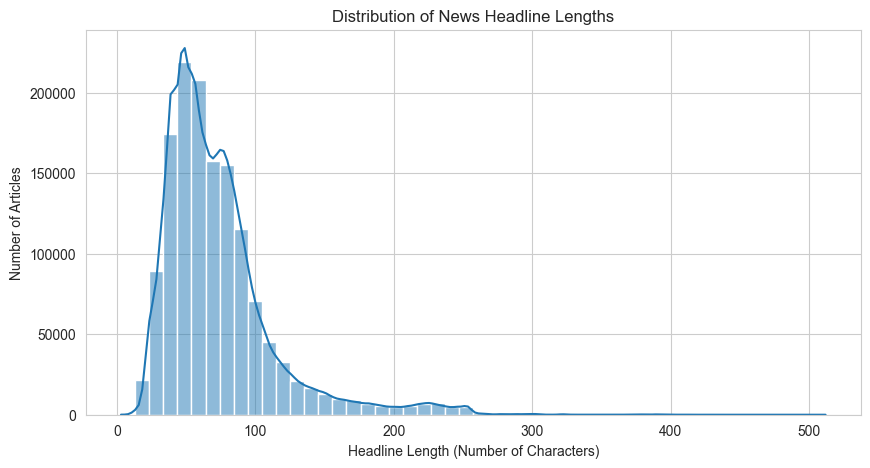

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_length'], bins=50, kde=True)
plt.title('Distribution of News Headline Lengths')
plt.xlabel('Headline Length (Number of Characters)')
plt.ylabel('Number of Articles')
plt.show()

Top Publisher Analysis

In [7]:
publisher_counts = df['publisher'].value_counts()
top_10_publishers = publisher_counts.head(10)

print("\n--- Top 10 News Publishers by Article Count ---")
print(top_10_publishers)


--- Top 10 News Publishers by Article Count ---
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


Visualize Publishers

C:\Users\bezaw\AppData\Local\Temp\ipykernel_14100\2459153393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_publishers.index, y=top_10_publishers.values, palette="viridis")


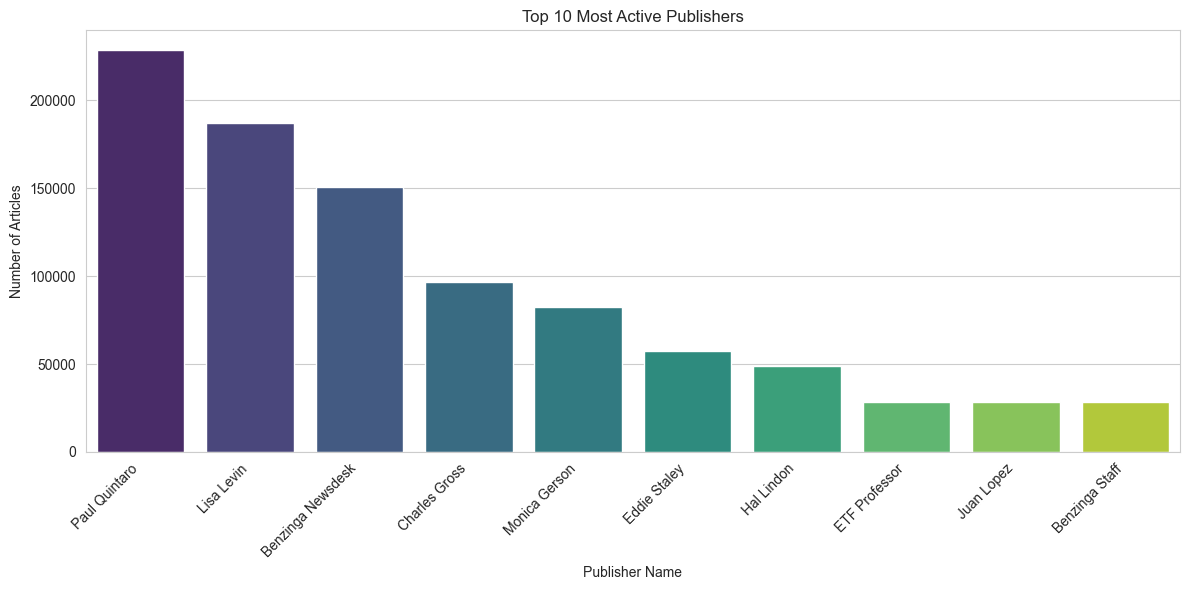

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_publishers.index, y=top_10_publishers.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

Time series analysis: converting columns into datetime object.

In [11]:
# --- CORRECTED TIME SERIES ANALYSIS SETUP ---

# 1. Convert the 'date' column to datetime objects, allowing mixed formats.
# We also use errors='coerce' to turn bad strings into NaT.
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

# Drop any rows where the date couldn't be parsed (now NaT)
df.dropna(subset=['date'], inplace=True)
print(f"Cleaned data: {len(df)} rows remain after dropping unparsed dates.")

# 2. Normalize Timezones
def normalize_tz(dt):
    # Check if the datetime object is timezone-aware
    if dt.tzinfo is not None and dt.tzinfo.utcoffset(dt) is not None:
        # Convert to UTC and make it timezone-naive (by removing the tz info)
        return dt.tz_convert('UTC').tz_localize(None)
    else:
        # If naive, treat it as if it were UTC and make it naive
        # This is a safe assumption for most financial news timestamps
        return dt

# Apply the normalization function to the date column
df['date'] = df['date'].apply(normalize_tz)


# 3. Set Index and Sort
# Set the date as the index and sort for time series analysis
df = df.set_index('date').sort_index()

# 4. Extract key time features (the rest of the original code)
df['day_of_week'] = df.index.day_name()
df['hour'] = df.index.hour

print("\nDate column successfully set as index and sorted!")
print(df.head())

Cleaned data: 172 rows remain after dropping unparsed dates.

Date column successfully set as index and sorted!
                     Unnamed: 0  \
date                              
2020-05-22 12:06:17      322775   
2020-05-22 12:06:17           9   
2020-05-22 12:37:59           8   
2020-05-22 13:07:04           7   
2020-05-22 13:36:20           6   

                                                              headline  \
date                                                                     
2020-05-22 12:06:17         10 Biggest Price Target Changes For Friday   
2020-05-22 12:06:17         10 Biggest Price Target Changes For Friday   
2020-05-22 12:37:59  Wells Fargo Maintains Overweight on Agilent Te...   
2020-05-22 13:07:04  Agilent Technologies shares are trading higher...   
2020-05-22 13:36:20  UBS Maintains Neutral on Agilent Technologies,...   

                                                                   url  \
date                                             

Analyze Daily Frequency: We count the number of articles per day to see the publication frequency over the entire dataset period.

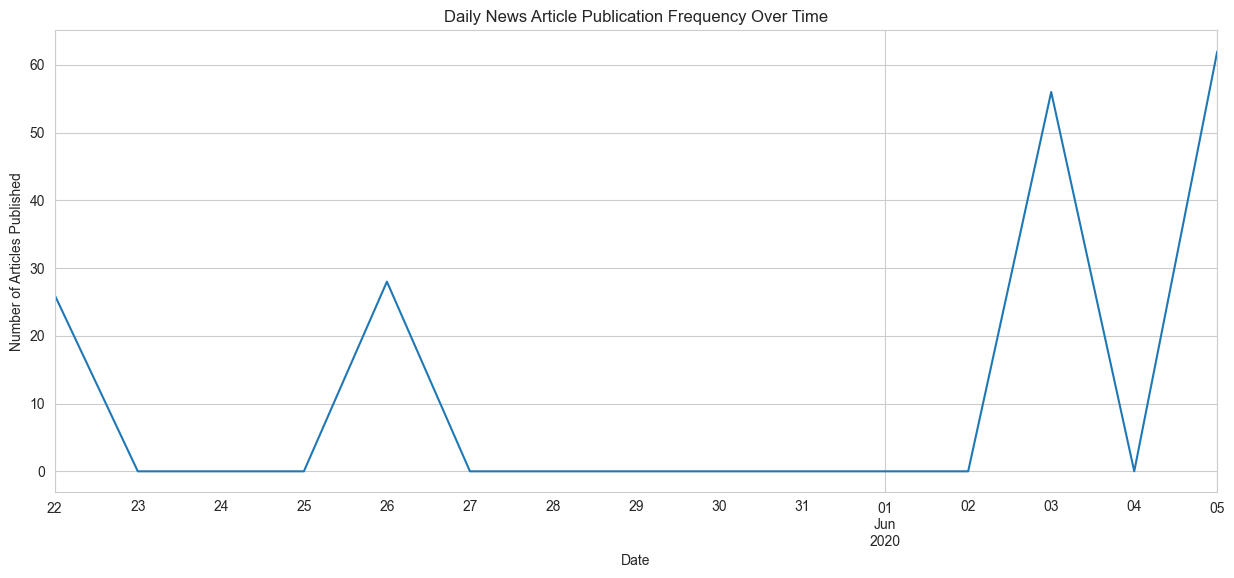

In [12]:
# Resample the data to count articles per day
daily_frequency = df.resample('D').size()

plt.figure(figsize=(15, 6))
daily_frequency.plot(kind='line')
plt.title('Daily News Article Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles Published')
plt.show()

Analyze Hourly Frequency: This is crucial for traders, is news released before, during or after market hours

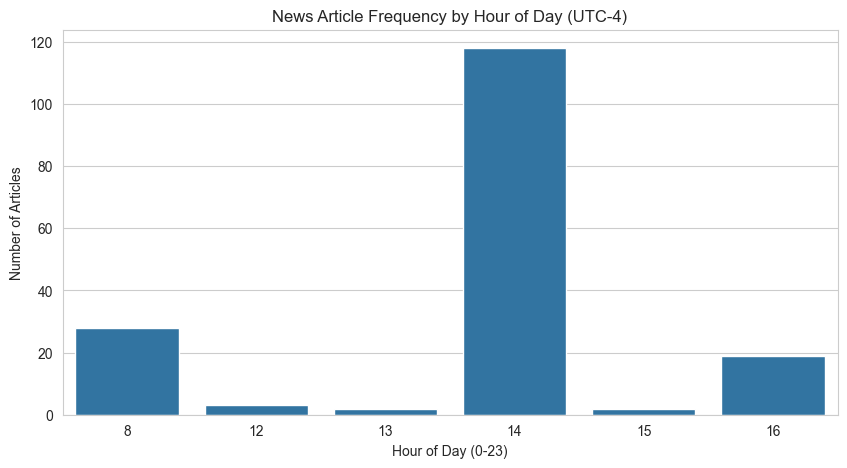

In [13]:
hourly_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title('News Article Frequency by Hour of Day (UTC-4)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Articles')
plt.show()

Text analysis>Cleaning the text by removing punctuation and stop words

In [14]:
# Ensure NLTK stopwords are available
try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

def clean_and_tokenize(text):
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stop words
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bezaw\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Apply function and count words : We apply the cleaning function to all headlines and flatten the list to count every single word.

In [15]:
# Apply the function to all headlines and collect all words
all_words = []
for headline in df['headline']:
    all_words.extend(clean_and_tokenize(headline))

# Count the frequency of each word
word_counts = pd.Series(all_words).value_counts()
top_20_words = word_counts.head(20)

print("\n--- Top 20 Most Common Keywords in Headlines ---")
print(top_20_words)


--- Top 20 Most Common Keywords in Headlines ---
stocks          137
highs           118
hit             118
52week          118
friday           92
wednesday        56
biggest          30
movers           28
moving           19
midday           19
fridays          19
session          19
price             6
target            6
technologies      5
agilent           5
maintains         4
raises            3
changes           2
neutral           2
Name: count, dtype: int64


Visualize keywords: A simple bar chart helps visualize the most relevant topics in your data

C:\Users\bezaw\AppData\Local\Temp\ipykernel_14100\1692958436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_words.index, y=top_20_words.values, palette="rocket")


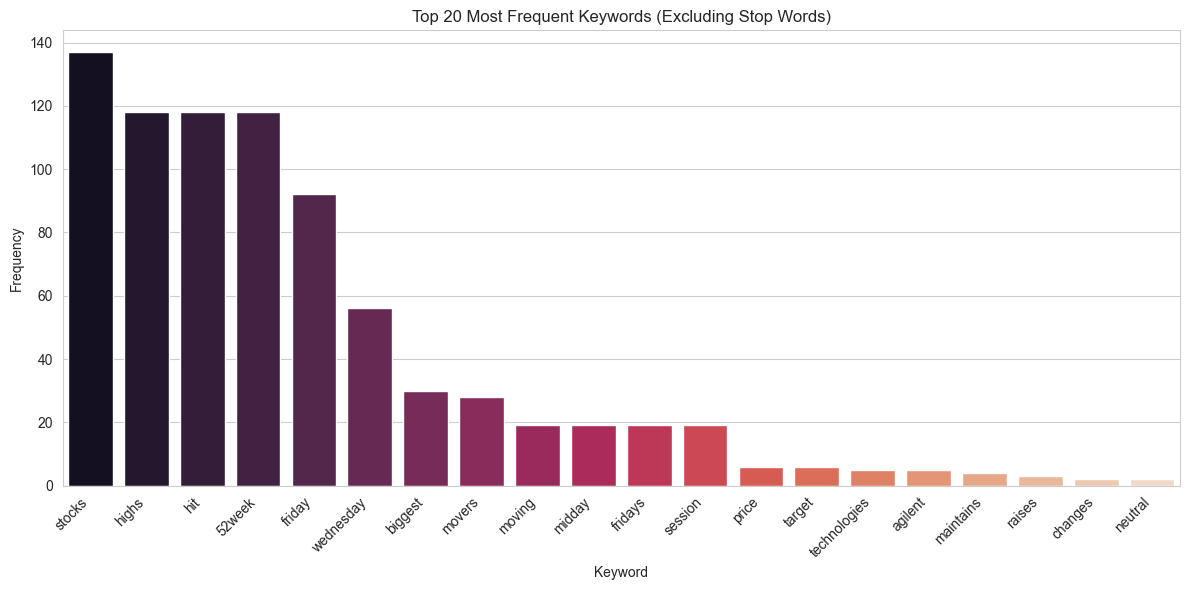

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_words.index, y=top_20_words.values, palette="rocket")
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Keywords (Excluding Stop Words)')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()